### Import Libraries

In [22]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

### Data Collection

In [6]:
df=pd.read_csv('Price Category.csv')

In [7]:
df

,Size (sq ft),Bedrooms,Price Category
0,2526,6,Expensive
1,2859,6,Expensive
2,2260,3,Expensive
3,2694,6,Expensive
4,2530,3,Expensive
...,...,...,...
95,1855,5,Expensive
96,2885,4,Expensive
97,2675,2,Expensive
98,2416,5,Expensive


### Data Cleaning/ Processing

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Size (sq ft)    100 non-null    int64 
 1   Bedrooms        100 non-null    int64 
 2   Price Category  100 non-null    object
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [9]:
df.describe()

,Size (sq ft),Bedrooms
count,100.00000,100.000000
mean,2259.98000,3.970000
std,477.47486,1.480206
min,1413.00000,2.000000
25%,1858.00000,2.000000
50%,2284.00000,4.000000
75%,2694.00000,5.000000
max,2990.00000,6.000000


### Feature Selection

In [10]:
x=df.drop('Price Category', axis=1)

In [11]:
y=df['Price Category']

##### split data into training and test data

In [12]:
from sklearn.model_selection import train_test_split 

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train

,Size (sq ft),Bedrooms
55,1566,6
88,2979,4
26,1676,3
42,2357,4
69,2355,2
...,...,...
60,1413,6
71,2851,5
14,2523,2
92,1669,2


### Model Selection using Logistics Regression

##### other classification algorigthm includes KNN Classifier, DecisionTree Classifier etc

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
log_model=LogisticRegression()

### Training

In [20]:
log_model.fit(x_train,y_train)

LogisticRegression()

### Evaluation

In [21]:
df

,Size (sq ft),Bedrooms,Price Category
0,2526,6,Expensive
1,2859,6,Expensive
2,2260,3,Expensive
3,2694,6,Expensive
4,2530,3,Expensive
...,...,...,...
95,1855,5,Expensive
96,2885,4,Expensive
97,2675,2,Expensive
98,2416,5,Expensive


In [23]:
f_x_input= np.array([2500,1]).reshape(1,-1)

In [24]:
log_model.predict(f_x_input)

array(['Expensive'], dtype=object)

In [26]:
fb_x_input= np.array([890,1]).reshape(1,-1)

In [27]:
log_model.predict(fb_x_input)

array(['Affordable'], dtype=object)

In [29]:
predicted_y_test=log_model.predict(x_test)

In [30]:
y_test

83     Expensive
53    Affordable
70     Expensive
45     Expensive
44     Expensive
39     Expensive
22     Expensive
80     Expensive
10    Affordable
0      Expensive
18     Expensive
30    Affordable
73     Expensive
33     Expensive
90    Affordable
4      Expensive
76     Expensive
77     Expensive
12     Expensive
31     Expensive
Name: Price Category, dtype: object

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,predicted_y_test)

1.0

In [34]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [35]:
confusion_matrix(y_test,predicted_y_test)

array([[ 4,  0],
       [ 0, 16]])

In [36]:
import seaborn as sns

<Axes: >

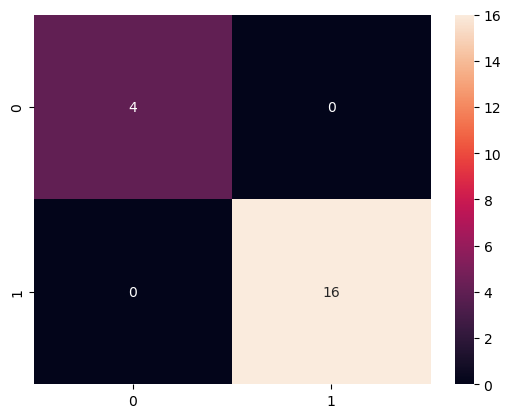

In [40]:
sns.heatmap(confusion_matrix(y_test,predicted_y_test),annot=True)

In [41]:
import joblib

In [43]:
joblib.dump(log_model,'Log_model.pkl')

['Log_model.pkl']